### Remove the beams 10 and 11

In [1]:
import torch
import numpy as np
import random
import os

def set_seed(seed: int = 42) -> None:
    """
    Sets the random seed for reproducibility across multiple libraries.
    """
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # For multi-GPU models
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"Random seed set as {seed}")

# Usage:
set_seed(30)

Random seed set as 30


In [2]:
model = torch.load('nets/siren/first_300_320.pt', weights_only=False)
mask = model['masker']

In [5]:
import torch
import Modules.preprocess as pp
import numpy as np 

data  = torch.load('../../data/data.pt', weights_only=True)
frames = np.arange(300, 320, 1)
beams = list(range(0,32))
w_0 =30
# beams.remove(1)
# beams.remove(3)
# beams.remove(30)
# beams.remove(29)

datasets = pp.data_gen(data =data, beams = beams, frames = frames, normalize='SS',splits = .8, w_0=w_0)
train_dataloader, ver_dataloader = datasets.get_dataloaders(num_workers =4, batch_size = 1)



In [6]:
t_dataset = datasets.get_datasets()[0]

x = t_dataset.__getitem__(0)

print(x[0].min(), x[0].max(), x[0].std())

tensor(-0.1856) tensor(0.1558) tensor(0.0563)


In [7]:
import Modules.trainers as tr
import torch
from Modules.Neural_Net import Net
# model_config = model['model config']
model_config = (3, 280, 550,1000,1000, 100, 100)
net = Net(torch.sin, *model_config, w_0 = w_0).to('cuda')
optimizer = torch.optim.Adam(net.parameters(), lr=1e-4)

ModuleList(
  (0): Linear(in_features=3, out_features=280, bias=True)
  (1): Linear(in_features=280, out_features=550, bias=True)
  (2): Linear(in_features=550, out_features=1000, bias=True)
  (3): Linear(in_features=1000, out_features=1000, bias=True)
  (4): Linear(in_features=1000, out_features=100, bias=True)
  (5): Linear(in_features=100, out_features=100, bias=True)
)


In [8]:
'Start training'
path = 'nets/siren/test_300_320.pt'


trainer =  tr.training(device='cuda', dataloader= train_dataloader, model_config=model_config,
                        optimizer=optimizer, net=net, scalers=datasets.get_scalers(), masker=datasets.get_mask() )

loss_curve = trainer.MSE_training(100, prints=True, saving=True, 
                                save_path=path,
                                  ver_dataloader=ver_dataloader, tolerance=None, loss_curve=False)


Epoch 0, Batch 0, Loss: 0.620778
Epoch 0 Complete - Avg Loss: 0.336976
Epoch 1, Batch 0, Loss: 0.496290
Epoch 1 Complete - Avg Loss: 0.251039
Epoch 2, Batch 0, Loss: 0.250028
Epoch 2 Complete - Avg Loss: 0.156784
Epoch 3, Batch 0, Loss: 0.135327
Epoch 3 Complete - Avg Loss: 0.124994
Epoch 4, Batch 0, Loss: 0.128344
Epoch 4 Complete - Avg Loss: 0.088160
Epoch 5, Batch 0, Loss: 0.068589
Epoch 5 Complete - Avg Loss: 0.097712
Epoch 6, Batch 0, Loss: 0.058760
Epoch 6 Complete - Avg Loss: 0.071972
Epoch 7, Batch 0, Loss: 0.044071
Epoch 7 Complete - Avg Loss: 0.046209
Epoch 8, Batch 0, Loss: 0.048198
Epoch 8 Complete - Avg Loss: 0.030210
Epoch 9, Batch 0, Loss: 0.024847
Epoch 9 Complete - Avg Loss: 0.033459
Epoch 10, Batch 0, Loss: 0.015988
Epoch 10 Complete - Avg Loss: 0.027580
Epoch 11, Batch 0, Loss: 0.024969
Epoch 11 Complete - Avg Loss: 0.020003
Epoch 12, Batch 0, Loss: 0.020088
Epoch 12 Complete - Avg Loss: 0.025681
Epoch 13, Batch 0, Loss: 0.018173
Epoch 13 Complete - Avg Loss: 0.02181

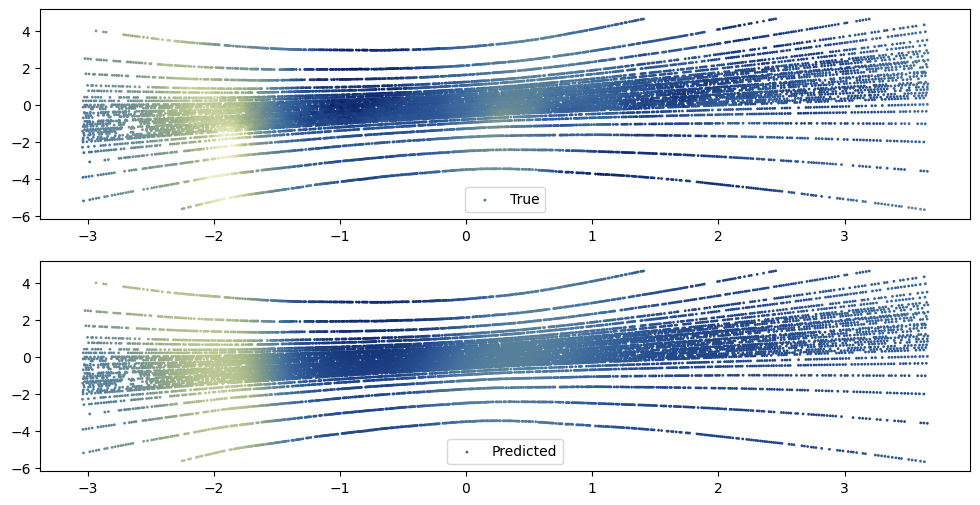

In [5]:
import matplotlib.pyplot as plt
import cmcrameri.cm as cmc

input_batch, output_batch = next(iter(train_dataloader))
input_batch = input_batch.to('cuda')
with torch.no_grad():
    pred_batch = net(input_batch)

x = input_batch.cpu().numpy().reshape(-1, 3)[:,0]
y = input_batch.cpu().numpy().reshape(-1, 3)[:,1]



fig, (ax1, ax2 ) = plt.subplots(2,figsize=(12,6))


ax1.scatter(x, y, c= output_batch.cpu().numpy().flatten(), cmap = cmc.davos,  label='True', s=1, vmin= -3, vmax=6)

ax2.scatter(x, y, c= pred_batch.cpu().numpy().flatten(), cmap = cmc.davos,  label='Predicted',s=1, vmin= -3, vmax=6)
ax1.legend()
ax2.legend()
plt.show()



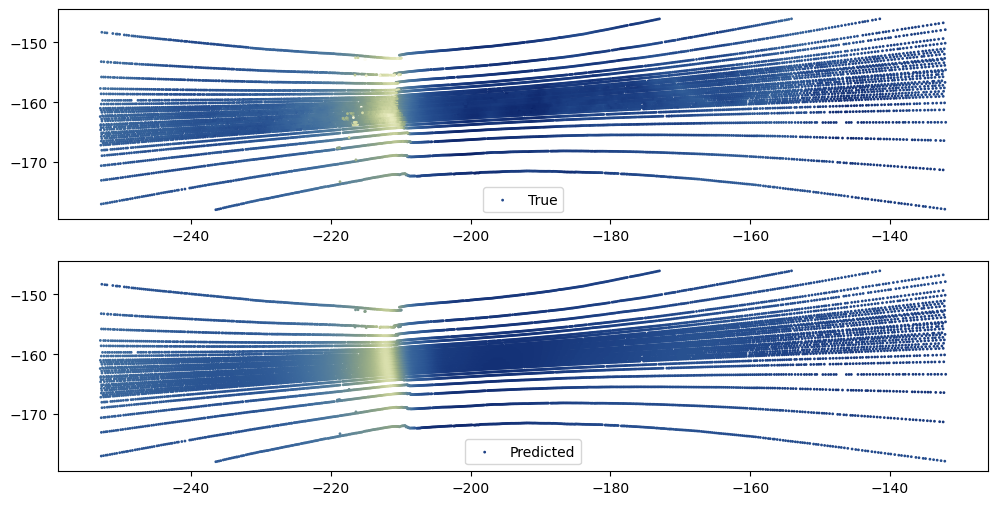

In [ ]:
'scaled plotting'
t = 30.2

input_batch, output_batch = next(iter(train_dataloader))
input_batch = input_batch.to('cuda')
with torch.no_grad():
    pred_batch = net(input_batch)

input_scaler, output_scaler = train_data.get_scalers()

input_batch_unscaled = input_scaler.inverse_transform(input_batch.cpu().numpy().reshape(-1,3))
pred_batch_unscaled = output_scaler.inverse_transform(pred_batch.cpu().numpy().reshape(-1,1))
output_batch_unscaled = output_scaler.inverse_transform(output_batch.cpu().numpy().reshape(-1,1))
x = input_batch_unscaled[:,0]
y = input_batch_unscaled[:,1]
fig, (ax1, ax2 ) = plt.subplots(2,figsize=(12,6))

ax1.scatter(x, y, c= output_batch_unscaled, cmap = cmc.davos,  label='True', s=1, vmin = 0, vmax=6)
ax2.scatter(x, y, c= pred_batch_unscaled.flatten(), cmap = cmc.davos,  label='Predicted',s=1, vmin = 0, vmax=6)
ax1.legend()
ax2.legend()
plt.show()


# Old Work


In [4]:
import os
import multiprocessing
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
os.environ['OMP_NUM_THREADS'] = '6'
os.environ['MKL_NUM_THREADS'] = '6'
os.environ['OPENBLAS_NUM_THREADS'] = '6'
os.environ['NUMEXPR_NUM_THREADS'] = '6'
os.environ['VECLIB_MAXIMUM_THREADS'] = '6'
os.environ['BLAS_NUM_THREADS'] = '6'

# Force multiprocessing to respect thread limits
multiprocessing.set_start_method('spawn', force=True)
from Modules import pre_pro
import torch
from torch.utils.data import TensorDataset, DataLoader
from Modules.Neural_Net import Net
from Modules.Losses import crit
import numpy as np
from Modules.beams import beam_trim
import matplotlib.pyplot as plt

In [3]:
data = torch.load('../../data/data.pt', weights_only=True)
frames = np.arange(250,350, 1)
device = 'cuda'

beams = list(range(0, 32))
indices_to_remove = [10, 11]
beams = [b for i, b in enumerate(beams) if i not in indices_to_remove]

with torch.no_grad():
    input, output = pre_pro.in_out(data, beams=beams, frames=frames)

dataloader = pre_pro.batching(input, output, workers=4)




NameError: name 'torch' is not defined

In [3]:
'Network set up'
network_info = torch.load('nets/MSE/MSE_250_350.pt', weights_only=True)

model_config = (3, 528 ,1024 , 1024, 528, 528)
net = Net(torch.cos, *model_config).to(device)
# net.load_state_dict(network_info['model_state_dict'])
optimizer = torch.optim.Adam(net.parameters(), lr=1e-4)
# optimizer.load_state_dict(network_info['optimizer_state_dict'])
# for param_group in optimizer.param_groups:
#     param_group['lr'] = 1e-4


In [ ]:
'Traing MSE NN'
save_path = 'nets/MSE/MSE_250_350.pt'
trainer = pre_pro.temp_nn_wrap('cuda', dataloader,model_config,optimizer, net )
trainer.MSE_train(10, prints=True, saving=True, save_path= save_path)

Epoch 0, Batch 0, Loss: 3.823828
Epoch 0, Batch 1, Loss: 2.645728
Epoch 0, Batch 2, Loss: 1.862659
Epoch 0, Batch 3, Loss: 1.240825
Epoch 0, Batch 4, Loss: 0.842804
Epoch 0, Batch 5, Loss: 0.694655
Epoch 0, Batch 6, Loss: 0.697706
Epoch 0, Batch 7, Loss: 0.761278
Epoch 0, Batch 8, Loss: 0.836143
Epoch 0, Batch 9, Loss: 0.878005
Epoch 0, Batch 10, Loss: 0.857117
Epoch 0, Batch 11, Loss: 0.791058
Epoch 0, Batch 12, Loss: 0.729873
Epoch 0, Batch 13, Loss: 0.678439
Epoch 0, Batch 14, Loss: 0.682102
Epoch 0, Batch 15, Loss: 0.717581
Epoch 0, Batch 16, Loss: 0.740039
Epoch 0, Batch 17, Loss: 0.764772
Epoch 0, Batch 18, Loss: 0.742212
Epoch 0, Batch 19, Loss: 0.706525
Epoch 0, Batch 20, Loss: 0.698804
Epoch 0, Batch 21, Loss: 0.674551
Epoch 0, Batch 22, Loss: 0.688321
Epoch 0, Batch 23, Loss: 0.712026
Epoch 0, Batch 24, Loss: 0.716464
Epoch 0, Batch 25, Loss: 0.711822
Epoch 0, Batch 26, Loss: 0.699942
Epoch 0, Batch 27, Loss: 0.694062
Epoch 0, Batch 28, Loss: 0.663846
Epoch 0, Batch 29, Loss:

(0.019959298619890913, 9)

In [4]:
'Adding in Regularazation'

network_info = torch.load('nets/MSE/MSE_250_350.pt', weights_only=True)
retrain_net = Net(torch.cos, *network_info['model config'])
retrain_net.load_state_dict(network_info['model_state_dict'])
retrain_net.to('cuda')
spt_optimizer = torch.optim.Adam(retrain_net.parameters(), lr = 0 )
spt_optimizer.load_state_dict(network_info['optimizer_state_dict'])
for param_group in spt_optimizer.param_groups:
    param_group['lr'] = 5e-5

In [ ]:
'New mini-batching'

dataset = pre_pro.FrameDataset(inputs_sorted=input, outputs_sorted= output)
spt_dataloader = DataLoader(dataset, pin_memory=True, num_workers=1, persistent_workers= True, batch_size=1)
it = iter(spt_dataloader)


In [ ]:
'Space Time Training-Hyperparameter Tunning'

retrainer = pre_pro.temp_nn_wrap('cuda', spt_dataloader, model_config=network_info['model config'],
                                  optimizer=spt_optimizer, net = retrain_net)

retrainer.SP_T_train(1, prints=True, saving= True, save_path='nets/SPT/spt_250_350.pt', ly =0 )

## New training style for ease of modularity
 Use modules trainers and preprocess.